In [2]:
# The Croston method is mainly used for forecasting intermittent demand.

# What is intermittent demand?
# It's a time series where:

# Many periods have zero demand
# Demand occurs irregularly
# When demand occurs, the quantity can vary
# Example:

# Month:   Jan Feb Mar Apr May Jun Jul Aug Sep Oct
# Demand:   0   0   8   0   0   5   0   0   0  12
#"When demand occurs, how much will it be, and how frequently will it occur?

In [3]:
# Using normal forecasting methods can be difficult because the model sees lots of zeros. Croston focuses specifically on the non-zero demand size
# and the time between non-zero demands.

In [4]:
# Croston is commonly used for inventory and supply-chain forecasting, especially:

# Spare parts
# Aircraft/automobile parts
# Machine components
# Maintenance materials
# Low-volume products
# Replacement parts
# Products with unpredictable purchasing patterns

In [5]:
# 1. Basic Croston
# Original Croston separates intermittent demand into two components:

# Demand size — how much is demanded when demand occurs
# Demand interval — how many periods between non-zero demands
# Period:  1  2  3  4  5  6  7  8  9
# Demand:  0  0  5  0  0  8  0  0  4
# The non-zero demand sizes are:
# 5,,8,4

In [6]:
# Forecast=estimated demand size/estimated demand interval

In [1]:
import pandas as pd
import numpy as np


In [2]:
data=pd.read_csv('synthetic_industrial_machine_data.csv')

In [3]:
data.head()

,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.3,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.0,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.4,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.5,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,62.2,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219000 entries, 0 to 218999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   transaction_date      219000 non-null  object 
 1   asset_tag             219000 non-null  object 
 2   machine_type          219000 non-null  object 
 3   plant_code            219000 non-null  object 
 4   part_no               219000 non-null  object 
 5   part_description      219000 non-null  object 
 6   part_family           219000 non-null  object 
 7   criticality           219000 non-null  object 
 8   uom                   219000 non-null  object 
 9   unit_cost_inr         219000 non-null  int64  
 10  qty_issued            219000 non-null  int64  
 11  issue_value_inr       219000 non-null  int64  
 12  temp_bearing_degC     219000 non-null  float64
 13  temp_motor_degC       219000 non-null  float64
 14  vibration_h_mms       219000 non-null  float64
 15  

In [5]:
data['transaction_date']=pd.to_datetime(data['transaction_date'])

In [6]:
data['asset_tag'].value_counts()

asset_tag
AST-1041    21900
AST-1042    21900
AST-2017    21900
AST-2031    21900
AST-3008    21900
AST-3019    21900
AST-4055    21900
AST-4061    21900
AST-5003    21900
AST-5007    21900
Name: count, dtype: int64

In [7]:
data['machine_type'].value_counts()

machine_type
CNC Lathe           43800
Hydraulic Press     43800
Belt Conveyor       43800
Screw Compressor    43800
EOT Crane           43800
Name: count, dtype: int64

In [8]:
data['plant_code'].value_counts()

plant_code
PUN-01    87600
CHN-02    65700
DHR-03    65700
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt

In [10]:
data.isnull().sum()

transaction_date             0
asset_tag                    0
machine_type                 0
plant_code                   0
part_no                      0
part_description             0
part_family                  0
criticality                  0
uom                          0
unit_cost_inr                0
qty_issued                   0
issue_value_inr              0
temp_bearing_degC            0
temp_motor_degC              0
vibration_h_mms              0
vibration_v_mms              0
oil_pressure_bar             0
load_pct                     0
shaft_rpm                    0
power_consumption_kw         0
breakdown_flag               0
wo_type                 176207
dtype: int64

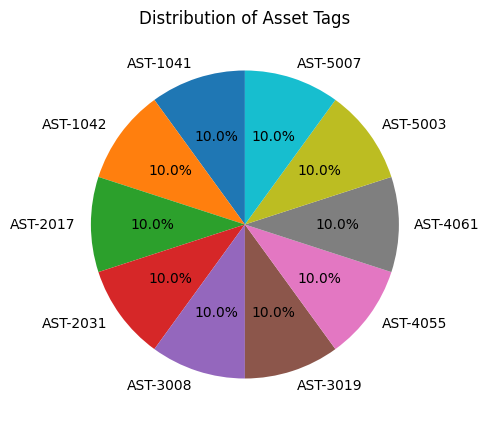

In [12]:
counts = data['asset_tag'].value_counts()

plt.figure(figsize=(10, 5))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Asset Tags")
plt.show()

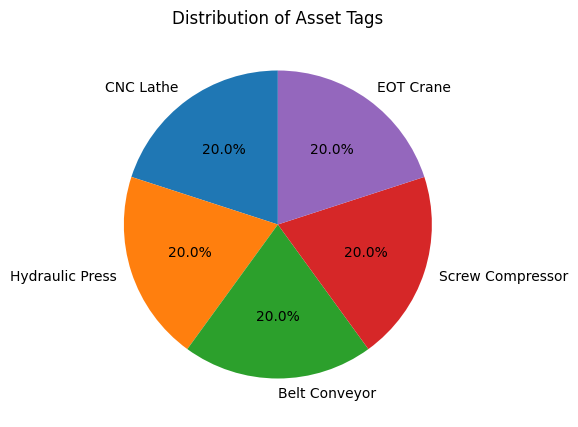

In [13]:
counts = data['machine_type'].value_counts()

plt.figure(figsize=(10, 5))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Asset Tags")
plt.show()

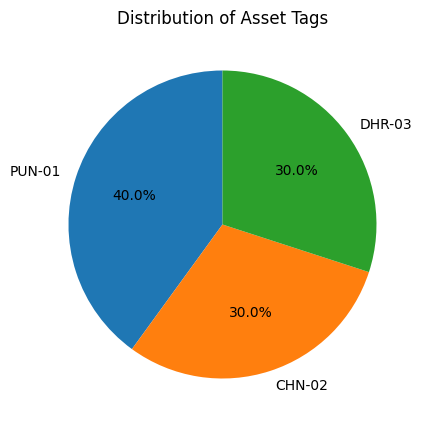

In [14]:
counts = data['plant_code'].value_counts()

plt.figure(figsize=(10, 5))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Asset Tags")
plt.show()

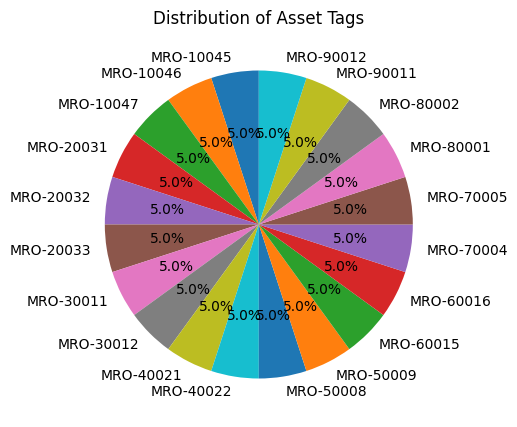

In [15]:

plt.figure(figsize=(10, 5))

plt.pie(
    data['part_no'].value_counts().values,
    labels=data['part_no'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Asset Tags")
plt.show()

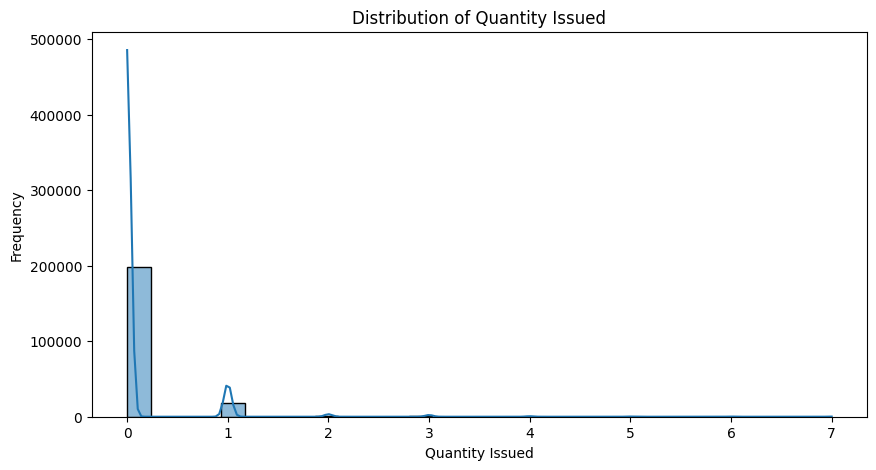

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x="qty_issued",
    bins=30,
    kde=True
)

plt.title("Distribution of Quantity Issued")
plt.xlabel("Quantity Issued")
plt.ylabel("Frequency")

plt.show()

In [17]:
data['part_description'].value_counts()

part_description
Deep Groove Ball Bearing 6205-2RS     10950
Cylindrical Roller Bearing NU-2210    10950
Taper Roller Bearing 30206            10950
Hydraulic Seal Kit 50mm Bore          10950
O-Ring NBR 75 Shore 40x3mm            10950
V-Ring Shaft Seal VS-35               10950
V-Belt A-68 Classical                 10950
Poly-V Belt 6PK1780                   10950
Hydraulic Filter Element 10 Micron    10950
Air Filter Cartridge AF-2500          10950
Carbon Brush Set 12.5x25mm            10950
Contactor LC1-D40 Coil 230V           10950
Coupling Spider (Jaw) 65 Shore        10950
Flexible Coupling Insert GR-38        10950
Grease Nipple M6x1 Straight           10950
Lithium EP-2 Grease 400g Cartridge    10950
Proximity Sensor PNP M12 2mm          10950
Thermocouple Type-K 200mm             10950
SS Fastener Hex Bolt M10x40 Gr8.8     10950
Lock Washer M10 Spring Type           10950
Name: count, dtype: int64

In [18]:
for col in data.columns:
    print(f"{col}----{data[col].value_counts()}")
    print("=================================")

transaction_date----transaction_date
2025-01-01    200
2022-01-03    200
2022-01-04    200
2022-01-05    200
2022-01-06    200
             ... 
2022-01-14    200
2022-01-13    200
2022-01-12    200
2022-01-11    200
2022-01-10    200
Name: count, Length: 1095, dtype: int64
asset_tag----asset_tag
AST-1041    21900
AST-1042    21900
AST-2017    21900
AST-2031    21900
AST-3008    21900
AST-3019    21900
AST-4055    21900
AST-4061    21900
AST-5003    21900
AST-5007    21900
Name: count, dtype: int64
machine_type----machine_type
CNC Lathe           43800
Hydraulic Press     43800
Belt Conveyor       43800
Screw Compressor    43800
EOT Crane           43800
Name: count, dtype: int64
plant_code----plant_code
PUN-01    87600
CHN-02    65700
DHR-03    65700
Name: count, dtype: int64
part_no----part_no
MRO-10045    10950
MRO-10046    10950
MRO-10047    10950
MRO-20031    10950
MRO-20032    10950
MRO-20033    10950
MRO-30011    10950
MRO-30012    10950
MRO-40021    10950
MRO-40022    10950
MRO

In [19]:
data.head()

,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.3,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.0,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.4,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.5,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,62.2,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219000 entries, 0 to 218999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_date      219000 non-null  datetime64[ns]
 1   asset_tag             219000 non-null  object        
 2   machine_type          219000 non-null  object        
 3   plant_code            219000 non-null  object        
 4   part_no               219000 non-null  object        
 5   part_description      219000 non-null  object        
 6   part_family           219000 non-null  object        
 7   criticality           219000 non-null  object        
 8   uom                   219000 non-null  object        
 9   unit_cost_inr         219000 non-null  int64         
 10  qty_issued            219000 non-null  int64         
 11  issue_value_inr       219000 non-null  int64         
 12  temp_bearing_degC     219000 non-null  float64       
 13 

In [21]:
df=data[['transaction_date','part_no','qty_issued']]

In [22]:
df.head()

,transaction_date,part_no,qty_issued
0,2022-01-03,MRO-10045,0
1,2022-01-04,MRO-10045,0
2,2022-01-05,MRO-10045,0
3,2022-01-06,MRO-10045,1
4,2022-01-07,MRO-10045,0


In [23]:
df.set_index('transaction_date')

,part_no,qty_issued
transaction_date,,
2022-01-03,MRO-10045,0
2022-01-04,MRO-10045,0
2022-01-05,MRO-10045,0
2022-01-06,MRO-10045,1
2022-01-07,MRO-10045,0
...,...,...
2024-12-28,MRO-90012,0
2024-12-29,MRO-90012,0
2024-12-30,MRO-90012,0


In [24]:
# why do we have to select only one part

# ChatGPT said:
# Because Croston forecasts one demand process at a time. In your dataset, each part_no represents a different demand process.

In [25]:
df['part_no'].unique()

array(['MRO-10045', 'MRO-10046', 'MRO-10047', 'MRO-20031', 'MRO-20032',
       'MRO-20033', 'MRO-30011', 'MRO-30012', 'MRO-40021', 'MRO-40022',
       'MRO-50008', 'MRO-50009', 'MRO-60015', 'MRO-60016', 'MRO-70004',
       'MRO-70005', 'MRO-80001', 'MRO-80002', 'MRO-90011', 'MRO-90012'],
      dtype=object)

In [26]:
df['part_no'].value_counts()

part_no
MRO-10045    10950
MRO-10046    10950
MRO-10047    10950
MRO-20031    10950
MRO-20032    10950
MRO-20033    10950
MRO-30011    10950
MRO-30012    10950
MRO-40021    10950
MRO-40022    10950
MRO-50008    10950
MRO-50009    10950
MRO-60015    10950
MRO-60016    10950
MRO-70004    10950
MRO-70005    10950
MRO-80001    10950
MRO-80002    10950
MRO-90011    10950
MRO-90012    10950
Name: count, dtype: int64

In [27]:
part = df[df["part_no"] == "MRO-10045"].copy()

In [28]:
part.set_index('transaction_date',inplace=True)

In [29]:
part.head()

,part_no,qty_issued
transaction_date,,
2022-01-03,MRO-10045,0
2022-01-04,MRO-10045,0
2022-01-05,MRO-10045,0
2022-01-06,MRO-10045,1
2022-01-07,MRO-10045,0


In [30]:
part.dtypes

part_no       object
qty_issued     int64
dtype: object

In [31]:
daily = part["qty_issued"].resample("D").sum()

In [32]:
daily.sample(10)

transaction_date
2023-03-15    1
2023-07-28    0
2024-05-12    0
2022-01-27    0
2023-10-06    0
2023-11-05    0
2022-05-12    1
2022-07-13    1
2022-05-03    0
2022-10-11    1
Name: qty_issued, dtype: int64

In [33]:
daily = (
    part["qty_issued"]
    .resample("D")
    .sum()
    .fillna(0)
)

In [34]:
daily

transaction_date
2022-01-03    2
2022-01-04    0
2022-01-05    0
2022-01-06    2
2022-01-07    1
             ..
2024-12-28    0
2024-12-29    0
2024-12-30    3
2024-12-31    1
2025-01-01    0
Freq: D, Name: qty_issued, Length: 1095, dtype: int64

In [35]:
print(daily.head(20))
print(daily.shape)
print(daily.describe())

transaction_date
2022-01-03    2
2022-01-04    0
2022-01-05    0
2022-01-06    2
2022-01-07    1
2022-01-08    0
2022-01-09    0
2022-01-10    2
2022-01-11    0
2022-01-12    1
2022-01-13    2
2022-01-14    1
2022-01-15    0
2022-01-16    0
2022-01-17    1
2022-01-18    3
2022-01-19    2
2022-01-20    0
2022-01-21    0
2022-01-22    0
Freq: D, Name: qty_issued, dtype: int64
(1095,)
count    1095.000000
mean        0.753425
std         0.962470
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: qty_issued, dtype: float64


In [48]:
zero_days = (daily == 0).sum()
non_zero_days = (daily > 0).sum()
total_days = len(daily)

print("Total days:", total_days)
print("Zero-demand days:", zero_days)
print("Non-zero-demand days:", non_zero_days)
print("Zero %:", zero_days / total_days * 100)

Total days: 1095
Zero-demand days: 578
Non-zero-demand days: 517
Zero %: 52.785388127853885


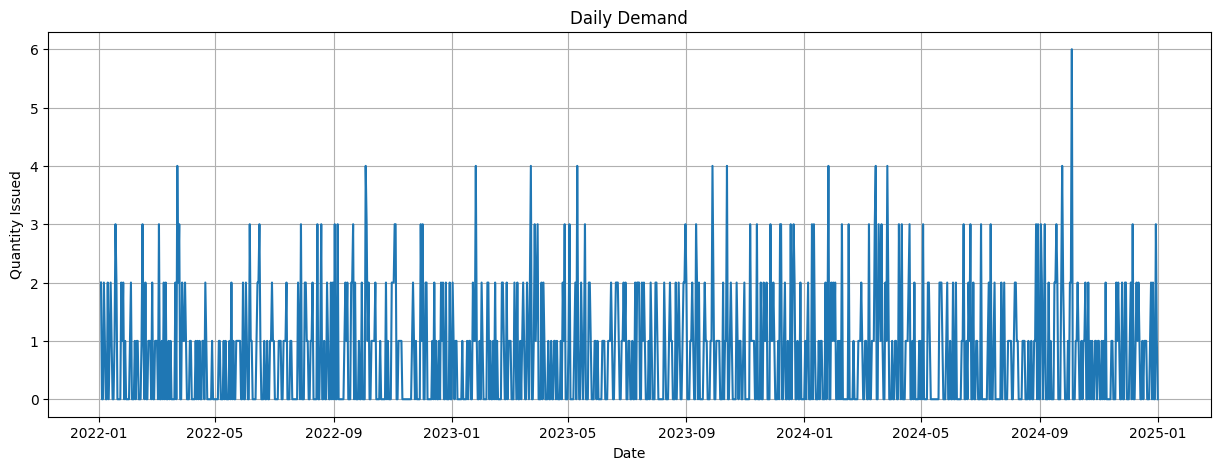

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(daily)

plt.title("Daily Demand")
plt.xlabel("Date")
plt.ylabel("Quantity Issued")
plt.grid(True)

plt.show()


In [50]:
non_zero = daily[daily > 0]

print(non_zero.describe())

count    517.000000
mean       1.595745
std        0.785664
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: qty_issued, dtype: float64


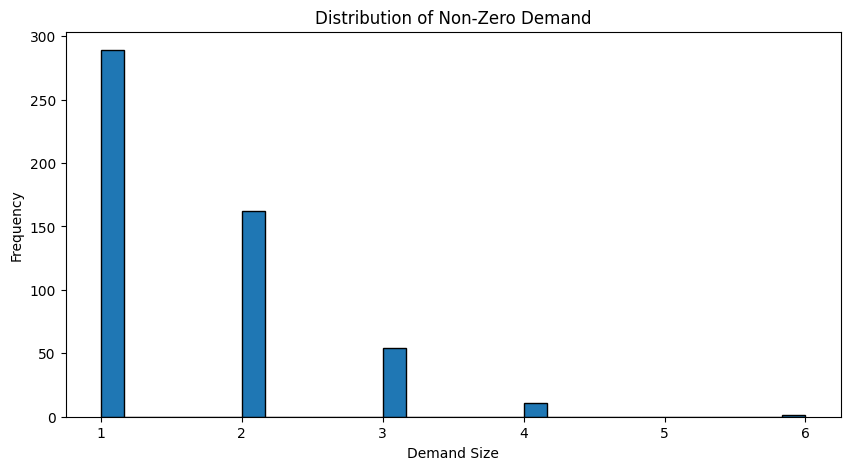

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    non_zero,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Demand Size")
plt.ylabel("Frequency")
plt.title("Distribution of Non-Zero Demand")

plt.show()


In [52]:
demand_dates = daily[daily > 0].index

print(demand_dates)

DatetimeIndex(['2022-01-03', '2022-01-06', '2022-01-07', '2022-01-10',
               '2022-01-12', '2022-01-13', '2022-01-14', '2022-01-17',
               '2022-01-18', '2022-01-19',
               ...
               '2024-12-13', '2024-12-16', '2024-12-18', '2024-12-19',
               '2024-12-20', '2024-12-24', '2024-12-25', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='transaction_date', length=517, freq=None)


In [53]:
intervals = demand_dates.to_series().diff().dt.days.dropna()
#Calculate the number of days between every consecutive non-zero demand.

In [54]:
intervals

transaction_date
2022-01-06    3.0
2022-01-07    1.0
2022-01-10    3.0
2022-01-12    2.0
2022-01-13    1.0
             ... 
2024-12-24    4.0
2024-12-25    1.0
2024-12-27    2.0
2024-12-30    3.0
2024-12-31    1.0
Name: transaction_date, Length: 516, dtype: float64

In [55]:
intervals.describe()

count    516.000000
mean       2.118217
std        1.507128
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max       11.000000
Name: transaction_date, dtype: float64

In [56]:
train = daily.iloc[:-30]
test = daily.iloc[-30:]

print("Train:", len(train))
print("Test:", len(test))

Train: 1065
Test: 30


In [83]:
 #!pip install statsforecast


In [62]:
from statsforecast import StatsForecast
from statsforecast.models import (
    CrostonClassic,
    CrostonSBA,
    CrostonOptimized,
    TSB
)

ModuleNotFoundError: No module named 'statsforecast'

In [63]:
import sys

print(sys.executable)
print(sys.version)

C:\Program Files\Python310\python.exe
3.10.0rc2 (tags/v3.10.0rc2:839d789, Sep  7 2021, 18:51:45) [MSC v.1929 64 bit (AMD64)]


In [84]:
# import sys

# print(sys.executable)

# !"{sys.executable}" -m pip install statsforecast

In [66]:
from statsforecast import StatsForecast

from statsforecast.models import (
    CrostonClassic,
    CrostonSBA,
    CrostonOptimized,
    TSB
)

print("StatsForecast is working!")

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


StatsForecast is working!


In [67]:
train

transaction_date
2022-01-03    2
2022-01-04    0
2022-01-05    0
2022-01-06    2
2022-01-07    1
             ..
2024-11-28    2
2024-11-29    2
2024-11-30    0
2024-12-01    0
2024-12-02    0
Freq: D, Name: qty_issued, Length: 1065, dtype: int64

In [68]:
train_df = train.reset_index()

In [69]:
train_df

,transaction_date,qty_issued
0,2022-01-03,2
1,2022-01-04,0
2,2022-01-05,0
3,2022-01-06,2
4,2022-01-07,1
...,...,...
1060,2024-11-28,2
1061,2024-11-29,2
1062,2024-11-30,0
1063,2024-12-01,0


In [70]:
train_df.columns = ["ds", "y"]

In [71]:
train_df

,ds,y
0,2022-01-03,2
1,2022-01-04,0
2,2022-01-05,0
3,2022-01-06,2
4,2022-01-07,1
...,...,...
1060,2024-11-28,2
1061,2024-11-29,2
1062,2024-11-30,0
1063,2024-12-01,0


In [72]:
train_df["unique_id"] = "MRO-10045"

train_df = train_df[
    ["unique_id", "ds", "y"]
]

print(train_df.head())

   unique_id         ds  y
0  MRO-10045 2022-01-03  2
1  MRO-10045 2022-01-04  0
2  MRO-10045 2022-01-05  0
3  MRO-10045 2022-01-06  2
4  MRO-10045 2022-01-07  1


In [74]:
models = [CrostonClassic(),CrostonSBA(),CrostonOptimized(),TSB(alpha_d=0.1, alpha_p=0.1)]

In [75]:
sf = StatsForecast(
    models=models,
    freq="D"
)

In [76]:
forecast = sf.forecast(
    df=train_df,
    h=30
)

print(forecast)

    unique_id         ds  CrostonClassic  CrostonSBA  CrostonOptimized  \
0   MRO-10045 2024-12-03        0.739819    0.702828          0.739819   
1   MRO-10045 2024-12-04        0.739819    0.702828          0.739819   
2   MRO-10045 2024-12-05        0.739819    0.702828          0.739819   
3   MRO-10045 2024-12-06        0.739819    0.702828          0.739819   
4   MRO-10045 2024-12-07        0.739819    0.702828          0.739819   
5   MRO-10045 2024-12-08        0.739819    0.702828          0.739819   
6   MRO-10045 2024-12-09        0.739819    0.702828          0.739819   
7   MRO-10045 2024-12-10        0.739819    0.702828          0.739819   
8   MRO-10045 2024-12-11        0.739819    0.702828          0.739819   
9   MRO-10045 2024-12-12        0.739819    0.702828          0.739819   
10  MRO-10045 2024-12-13        0.739819    0.702828          0.739819   
11  MRO-10045 2024-12-14        0.739819    0.702828          0.739819   
12  MRO-10045 2024-12-15        0.7398

In [77]:
test_df = test.reset_index()

test_df.columns = ["ds", "y"]

test_df["unique_id"] = "MRO-10045"


In [78]:
results = test_df.merge(
    forecast,
    on=["unique_id", "ds"],
    how="left"
)

print(results.head())

          ds  y  unique_id  CrostonClassic  CrostonSBA  CrostonOptimized  \
0 2024-12-03  1  MRO-10045        0.739819    0.702828          0.739819   
1 2024-12-04  2  MRO-10045        0.739819    0.702828          0.739819   
2 2024-12-05  0  MRO-10045        0.739819    0.702828          0.739819   
3 2024-12-06  3  MRO-10045        0.739819    0.702828          0.739819   
4 2024-12-07  0  MRO-10045        0.739819    0.702828          0.739819   

        TSB  
0  0.586428  
1  0.586428  
2  0.586428  
3  0.586428  
4  0.586428  


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model_names = [
    "CrostonClassic",
    "CrostonSBA",
    "CrostonOptimized",
    "TSB"
]

for model in model_names:

    mae = mean_absolute_error(
        results["y"],
        results[model]
    )

    rmse = np.sqrt(
        mean_squared_error(
            results["y"],
            results[model]
        )
    )

    print(
        f"{model}: "
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f}"
    )


CrostonClassic: MAE=0.77, RMSE=0.93
CrostonSBA: MAE=0.77, RMSE=0.94
CrostonOptimized: MAE=0.77, RMSE=0.93
TSB: MAE=0.79, RMSE=0.96


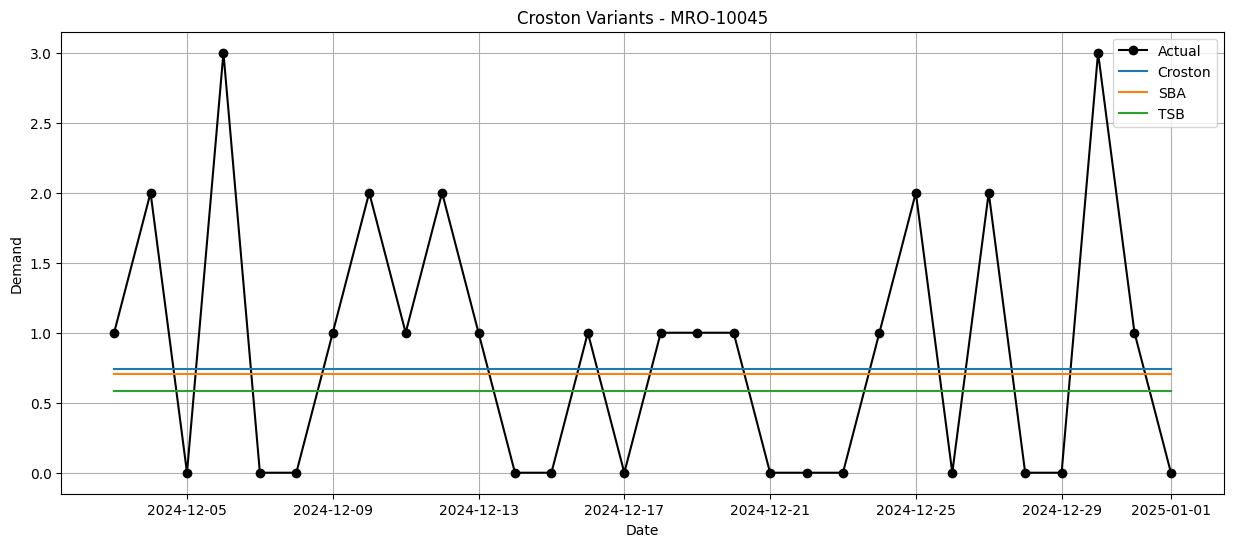

In [80]:
plt.figure(figsize=(15, 6))

plt.plot(
    results["ds"],
    results["y"],
    label="Actual",
    color="black",
    marker="o"
)

plt.plot(
    results["ds"],
    results["CrostonClassic"],
    label="Croston"
)

plt.plot(
    results["ds"],
    results["CrostonSBA"],
    label="SBA"
)

plt.plot(
    results["ds"],
    results["TSB"],
    label="TSB"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Croston Variants - MRO-10045")

plt.legend()
plt.grid(True)

plt.show()


In [82]:
from statsforecast import StatsForecast
from statsforecast.models import TSB
alpha_values = [0.05, 0.1, 0.2, 0.3, 0.5]
tsb_results = []

for alpha_d in alpha_values:
    for alpha_p in alpha_values:

        model = TSB(
            alpha_d=alpha_d,
            alpha_p=alpha_p
        )

        sf = StatsForecast(
            models=[model],
            freq="D"
        )

        forecast = sf.forecast(
            df=train_df,
            h=len(test)
        )

        results_tsb = test_df.merge(
            forecast,
            on=["unique_id", "ds"],
            how="left"
        )

        prediction_column = results_tsb.columns[-1]

        mae = mean_absolute_error(
            results_tsb["y"],
            results_tsb[prediction_column]
        )

        rmse = np.sqrt(
            mean_squared_error(
                results_tsb["y"],
                results_tsb[prediction_column]
            )
        )

        tsb_results.append({
            "alpha_d": alpha_d,
            "alpha_p": alpha_p,
            "MAE": mae,
            "RMSE": rmse
        })

tsb_results = pd.DataFrame(tsb_results)

print(
    tsb_results
    .sort_values("MAE")
    .head(10)
)

    alpha_d  alpha_p       MAE      RMSE
20     0.50     0.05  0.758398  0.922971
15     0.30     0.05  0.766176  0.928254
21     0.50     0.10  0.769581  0.931707
10     0.20     0.05  0.772771  0.935563
16     0.30     0.10  0.776557  0.940909
0      0.05     0.05  0.778237  0.943545
5      0.10     0.05  0.779469  0.945581
11     0.20     0.10  0.782470  0.950896
1      0.05     0.10  0.787371  0.960648
6      0.10     0.10  0.788476  0.963028


In [85]:
full_data = daily.copy()

In [86]:
forecast_df = full_data.reset_index()

forecast_df.columns = ["ds", "y"]

forecast_df["unique_id"] = "MRO-10045"

forecast_df = forecast_df[
    ["unique_id", "ds", "y"]
]

print(forecast_df.tail())

      unique_id         ds  y
1090  MRO-10045 2024-12-28  0
1091  MRO-10045 2024-12-29  0
1092  MRO-10045 2024-12-30  3
1093  MRO-10045 2024-12-31  1
1094  MRO-10045 2025-01-01  0


In [87]:
from statsforecast import StatsForecast
from statsforecast.models import CrostonOptimized

model = CrostonOptimized()

sf = StatsForecast(
    models=[model],
    freq="D"
)

In [88]:
future_forecast = sf.forecast(
    df=forecast_df,
    h=30
)
#StatsForecast uses the last date in forecast_df as the cutoff and predicts the next 30 periods.
print(future_forecast)

    unique_id         ds  CrostonOptimized
0   MRO-10045 2025-01-02          0.816945
1   MRO-10045 2025-01-03          0.816945
2   MRO-10045 2025-01-04          0.816945
3   MRO-10045 2025-01-05          0.816945
4   MRO-10045 2025-01-06          0.816945
5   MRO-10045 2025-01-07          0.816945
6   MRO-10045 2025-01-08          0.816945
7   MRO-10045 2025-01-09          0.816945
8   MRO-10045 2025-01-10          0.816945
9   MRO-10045 2025-01-11          0.816945
10  MRO-10045 2025-01-12          0.816945
11  MRO-10045 2025-01-13          0.816945
12  MRO-10045 2025-01-14          0.816945
13  MRO-10045 2025-01-15          0.816945
14  MRO-10045 2025-01-16          0.816945
15  MRO-10045 2025-01-17          0.816945
16  MRO-10045 2025-01-18          0.816945
17  MRO-10045 2025-01-19          0.816945
18  MRO-10045 2025-01-20          0.816945
19  MRO-10045 2025-01-21          0.816945
20  MRO-10045 2025-01-22          0.816945
21  MRO-10045 2025-01-23          0.816945
22  MRO-100

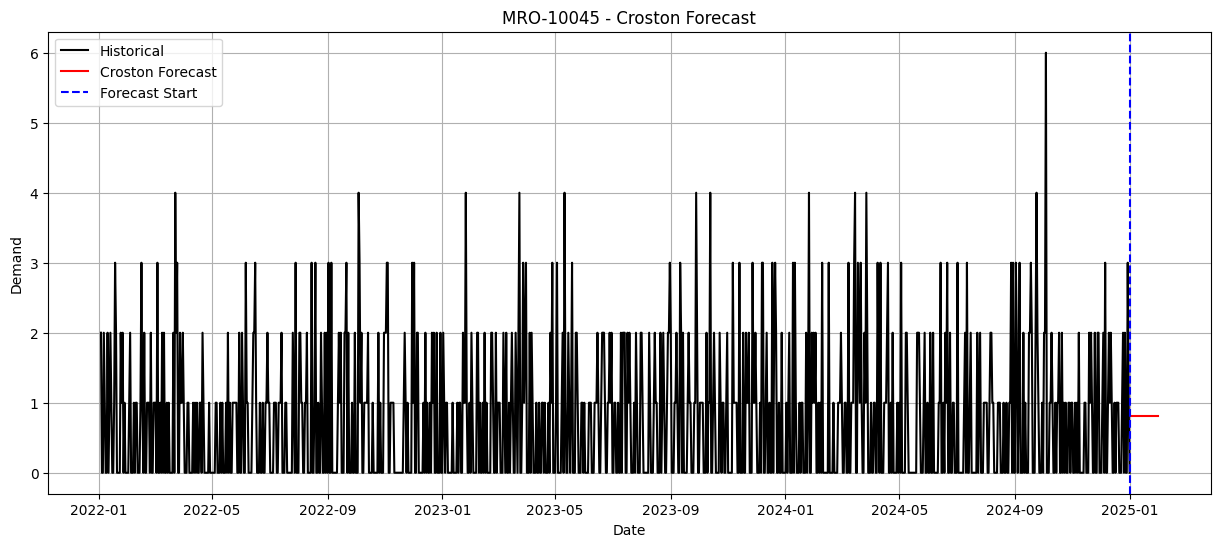

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Historical
plt.plot(
    forecast_df["ds"],
    forecast_df["y"],
    label="Historical",
    color="black"
)

# Future
plt.plot(
    future_forecast["ds"],
    future_forecast["CrostonOptimized"],
    label="Croston Forecast",
    color="red"
)

plt.axvline(
    forecast_df["ds"].max(),
    color="blue",
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("MRO-10045 - Croston Forecast")
plt.legend()
plt.grid(True)

plt.show()


In [91]:
total_forecast = future_forecast["CrostonOptimized"].sum()

print(total_forecast)

24.508366


In [92]:
# "Based on the historical intermittent-demand pattern of MRO-10045, expected demand is approximately 0.817 units per day."
# For 30 days:0.816945×30=24.50835
# So the expected total demand over the next 30 days is approximately:
# 24.5 units

In [93]:
print("Last historical date:")
print(forecast_df["ds"].max())

print("\nFirst forecast date:")
print(future_forecast["ds"].min())

print("\nLast forecast date:")
print(future_forecast["ds"].max())

Last historical date:
2025-01-01 00:00:00

First forecast date:
2025-01-02 00:00:00

Last forecast date:
2025-01-31 00:00:00


In [96]:
import inspect
print("Classic:", inspect.signature(CrostonClassic))
print("SBA:", inspect.signature(CrostonSBA))
print("Optimized:", inspect.signature(CrostonOptimized))
print("TSB:", inspect.signature(TSB))


Classic: (alias: str = 'CrostonClassic', prediction_intervals: Optional[statsforecast.utils.ConformalIntervals] = None)
SBA: (alias: str = 'CrostonSBA', prediction_intervals: Optional[statsforecast.utils.ConformalIntervals] = None)
Optimized: (alias: str = 'CrostonOptimized', prediction_intervals: Optional[statsforecast.utils.ConformalIntervals] = None)
TSB: (alpha_d: float, alpha_p: float, alias: str = 'TSB', prediction_intervals: Optional[statsforecast.utils.ConformalIntervals] = None)
